In [1]:
import shutil

In [1]:
import pandas as pd

In [17]:
import os
import pathlib
import numpy as np
import tensorflow as tf
from tensorflow import keras
import csv
from collections import Counter
import random
#from tensorflow.keras.layers.experimental.preprocessing import TextVectorization
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding
import matplotlib.pyplot as plt

In [5]:
import torch
from transformers import BertTokenizerFast, BertModel

In [5]:
def read_annotation(filename):
    events = []
    with open(filename, 'r') as csvfile:
        spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
        for row in spamreader:
            events.append(row)
    return events

In [6]:
events = read_annotation("eq_contributions.csv")
len(events)

1596

In [7]:
words_list = [e[0].lower() for e in events[1:] if e[1] == "English"]

In [8]:
len(words_list)

918

In [9]:
hq_words = ["bright","brittle","clear","crisp","harsh","hollow","sharp","shrill","tinny","woody","big","boom","boxy","dark","dull","fat","full","muddy","muffled","punch","smooth","sweet","warm","flat",
            "crunchy","deep","soothing","clean","airy","cold","metallic","booming"]

In [10]:
len(hq_words)

32

In [11]:
words_list[0:10]

['hot',
 'wet',
 'slow',
 'saucy',
 'heavy',
 'shrill',
 'warm',
 'chill',
 'sharp',
 'corn']

In [12]:
high_rated_words = list(set([e[0].lower() for e in events[1:] if e[1] == "English" and float(e[3]) > 0.7 and e[0].lower() not in hq_words]))
high_rated_words.sort()

In [13]:
high_rated_words

['aggressive',
 'baseball',
 'beautiful',
 'biting',
 'bold',
 'brash',
 'brass',
 'brassy',
 'breezy',
 'calm',
 'caring',
 'cheerful',
 'clarity',
 'cooing',
 'cool',
 'cute',
 'disgusting',
 'down',
 'edge',
 'edgy',
 'enchanting',
 'energetic',
 'energizing',
 'excited',
 'exciting',
 'fancy',
 'fluffy',
 'forceful',
 'frigid',
 'funky',
 'genius',
 'gentle',
 'good',
 'gruff',
 'happy',
 'hard',
 'heart-warming',
 'heat',
 'heavy',
 'hot',
 'huge',
 'icy',
 'jagged',
 'large',
 'light',
 'loud',
 'love',
 'low',
 'mellow',
 'mournful',
 'noisy',
 'passionate',
 'peace',
 'peaceful',
 'pleasing',
 'pleasurable',
 'plodding',
 'poor',
 'punchy',
 'quiet',
 'radiant',
 'relaxing',
 'reserved',
 'rich',
 'romantic',
 'rousing',
 'rumble',
 'serene',
 'sloppy',
 'slow',
 'soft',
 'solemn',
 'splash',
 'squeaking',
 'strong',
 'taco',
 'techno',
 'tense',
 'throbbing',
 'thumpy',
 'thunderous',
 'twangy',
 'velvety',
 'whispered',
 'whispering',
 'wistful']

In [14]:
len(high_rated_words)

86

In [15]:
# 5, 19, 71
# Using seed 302 for shuffling into folds
random.seed(302)
random.shuffle(hq_words)
random.shuffle(high_rated_words)
#test_word_set = hq_words[0:10] + high_rated_words[0:30]

In [16]:
test_word_set_1 = hq_words[0:9] + high_rated_words[0:22]
test_word_set_2 = hq_words[9:18] + high_rated_words[22:44]
test_word_set_3 = hq_words[18:27] + high_rated_words[44:66]

In [17]:
test_word_set_4 = hq_words[27:] + hq_words[0:4] + high_rated_words[66:] + high_rated_words[0:2]

In [18]:
test_word_set_4

['brittle',
 'booming',
 'sharp',
 'fat',
 'soothing',
 'dark',
 'warm',
 'boom',
 'woody',
 'whispering',
 'passionate',
 'radiant',
 'baseball',
 'beautiful',
 'strong',
 'biting',
 'wistful',
 'gentle',
 'pleasurable',
 'slow',
 'heart-warming',
 'genius',
 'heat',
 'peaceful',
 'fancy',
 'heavy',
 'brassy',
 'cheerful',
 'down',
 'brash',
 'techno']

In [19]:
cc = dict(Counter(words_list))

In [20]:
words_set = list(cc.keys())
words_set.sort()

In [21]:
len(words_set)

388

In [22]:
cc

{'hot': 8,
 'wet': 2,
 'slow': 2,
 'saucy': 1,
 'heavy': 15,
 'shrill': 4,
 'warm': 64,
 'chill': 1,
 'sharp': 8,
 'corn': 1,
 'soft': 29,
 'apple': 1,
 'deep': 6,
 'scary': 5,
 'oxygen': 1,
 'tinny': 8,
 'loud': 26,
 'flat': 3,
 'jarring': 3,
 'prickly': 1,
 'crunchy': 5,
 'excitement': 1,
 'cold': 34,
 'cool': 14,
 'relaxing': 4,
 'hard': 10,
 'light': 6,
 'funky': 4,
 'bright': 19,
 'fast': 5,
 'crisp': 8,
 'pretty': 2,
 'hollow': 3,
 'steep': 1,
 'classic': 2,
 'mellow': 8,
 'dark': 8,
 'tight': 1,
 'boom': 1,
 'sad': 9,
 'sunshine': 1,
 'fuzzy': 1,
 'carefree': 1,
 'woody': 1,
 'crunch': 1,
 'sweet': 5,
 'mournful': 1,
 'ralph': 1,
 'groovy': 1,
 'soothing': 17,
 'happy': 22,
 'damp': 1,
 'tiger': 1,
 'greasy': 1,
 'clear': 12,
 'pleasant': 6,
 'cheerful': 3,
 'creepy': 1,
 'nice': 3,
 'punch': 1,
 'delightful': 1,
 'balanced': 1,
 'car': 1,
 'gradual': 1,
 'calm': 13,
 'pleasing': 2,
 'love': 4,
 'metallic': 2,
 'cat': 2,
 'biting': 1,
 'serene': 3,
 'fast-paced': 1,
 'smooth': 1

# FourFolds

In [120]:
# Set test_word_set to test_word_set_1, test_word_set_2, test_word_set_3, test_word_set_4 for different folds
test_word_set = test_word_set_4

In [121]:
train_word_set = [w for w in words_set if w not in test_word_set]

In [122]:
train_events = [e for e in events[1:] if e[1] == "English" and e[0].lower() in train_word_set]

test_events = [e for e in events[1:] if e[1] == "English" and e[0].lower() in test_word_set and float(e[3]) > 0.7]

In [123]:
words_set = list(cc.keys())
words_set.sort()

In [124]:
train_samples = [e[0].lower() for e in train_events]
train_labels = [e[4:] for e in train_events]

test_samples = [e[0].lower() for e in test_events]
test_labels = [e[4:] for e in test_events]

In [125]:
print(len(train_events))
print(len(test_events))

751
47


In [126]:
train_samples

['hot',
 'wet',
 'saucy',
 'shrill',
 'chill',
 'corn',
 'soft',
 'apple',
 'deep',
 'scary',
 'oxygen',
 'tinny',
 'loud',
 'flat',
 'jarring',
 'prickly',
 'crunchy',
 'excitement',
 'cold',
 'cool',
 'relaxing',
 'cold',
 'hard',
 'light',
 'cool',
 'funky',
 'bright',
 'fast',
 'flat',
 'bright',
 'crisp',
 'pretty',
 'hollow',
 'soft',
 'steep',
 'classic',
 'hard',
 'cold',
 'mellow',
 'tight',
 'sad',
 'sunshine',
 'fuzzy',
 'carefree',
 'crunch',
 'sweet',
 'soft',
 'mournful',
 'tinny',
 'ralph',
 'relaxing',
 'soft',
 'groovy',
 'happy',
 'damp',
 'tinny',
 'tiger',
 'tinny',
 'greasy',
 'clear',
 'crisp',
 'pleasant',
 'soft',
 'cold',
 'creepy',
 'nice',
 'punch',
 'soft',
 'soft',
 'pleasant',
 'delightful',
 'crisp',
 'light',
 'balanced',
 'car',
 'gradual',
 'calm',
 'pleasing',
 'love',
 'metallic',
 'cat',
 'loud',
 'serene',
 'fast-paced',
 'smooth',
 'soft',
 'please',
 'upbeat',
 'loud',
 'tinny',
 'hello',
 'clear',
 'clash',
 'romantic',
 'dry',
 'breezy',
 'myst

In [127]:
train_labels

[['-1.287298455028059',
  '-1.5329640818066959',
  '-1.5065393849267092',
  '-1.396973938464201',
  '-1.2711989128944425',
  '-1.0178666691600544',
  '-0.5287290070088837',
  '0.16557358394555965',
  '0.7544001753754086',
  '1.0739920359101394',
  '1.2822107254240411',
  '1.4420600618966608',
  '1.5686854806911437',
  '1.6539996970983781',
  '1.6485038058321697',
  '1.5396735895749836',
  '1.5803471123103943',
  '1.577686577264061',
  '1.2056754706021262',
  '0.6767587910924957',
  '0.2528211232802435',
  '0.07516707774497841',
  '-0.03310109922334817',
  '-0.08911504670977308',
  '-0.1365393000994961',
  '-0.14356593912698262',
  '-0.08429928743358363',
  '-0.05102776676108934',
  '-0.03859115288560351',
  '-0.08974995193389214',
  '-0.1922442947227218',
  '-0.34500620431659407',
  '-0.529255496814794',
  '-0.7249892662082197',
  '-0.8647406029177945',
  '-0.9165421808075063',
  '-0.8395575771596734',
  '-0.8236119930372738',
  '-0.9809584059667169',
  '-1.0730892926286768'],
 ['-0.97

# Embedding Extraction

In [18]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
em_model = BertModel.from_pretrained('bert-base-uncased')


test_sentence = "This piece of music sounds relaxing."

#Tokenize the sentence and return PyTorch tensors
inputs = tokenizer(test_sentence, return_tensors="pt")

# Perform forward pass through the model
# Using no_grad() to avoid gradient computation and save memory
with torch.no_grad():
    outputs = em_model(**inputs)

# Extract the last hidden state (batch_size, sequence_length, hidden_size)
last_hidden_state = outputs.last_hidden_state

print("Shape of the hidden state:", last_hidden_state.shape)

Shape of the hidden state: torch.Size([1, 9, 768])


In [1]:
import torch.nn.functional as F

# Locate the target word in the tokenized sentence
def find_sublist(tokens, sub_tokens):
    n = len(sub_tokens)
    for i in range(len(tokens) - n + 1):
        if [t.lstrip("##") for t in tokens[i:i+n]] == [st.lstrip("##") for st in sub_tokens]:
            return i, i+n
    return None

def extract_target_vector(template, target_word):
    """
    Replace placeholder in template sentence, compute the average vector for the target word.
    """
    filled_sentence = template.replace("[MASK]", target_word)
    inputs = tokenizer(filled_sentence, return_tensors="pt", return_offsets_mapping=True)
    offset_mapping = inputs.pop("offset_mapping")  # Extract offset mapping
    
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"].squeeze())
    target_token_ids = tokenizer(target_word, add_special_tokens=False)["input_ids"]
    target_tokens = tokenizer.convert_ids_to_tokens(target_token_ids)
    
    
    
    match = find_sublist(tokens, target_tokens)
    if not match:
        raise ValueError("Target word tokens not found in the sentence.")
    start_idx, end_idx = match

    # Forward pass to obtain hidden states
    with torch.no_grad():
        outputs = em_model(**inputs)
    last_hidden_state = outputs.last_hidden_state  # (1, sequence_length, hidden_size)

    # Extract and average target token vectors
    target_vectors = last_hidden_state.squeeze()[start_idx:end_idx]
    avg_vector = target_vectors.mean(dim=0)
    return avg_vector

def compute_avg_vector(target_word, templates):
    vectors = [extract_target_vector(template, target_word) for template in templates]
    return torch.stack(vectors, dim=0).mean(dim=0)  # Average across all templates

In [2]:
templates = [
    "This music sounds [MASK].",  
    "The overall tone of this music is [MASK].",  
    #"This audio conveys a [MASK] emotion, shaping the listener's perception.",  
    #"The resonance and texture of this recording are distinctly [MASK].",  
    "The spectral balance and tonal quality of this music feel [MASK], defining its timbre.",  
    #"The post-processing techniques have enhanced the sound, making it [MASK]." 
]

In [34]:
embedding_dict = {}

# 遍历 words_set 中的每个词，提取该词的 768 维嵌入
for word in words_set:
    try:
        embedding = compute_avg_vector(word, templates)
        embedding_dict[word] = embedding  # 将单词及其嵌入保存到字典中
        #print(f"【成功】{word} 的嵌入提取成功。")
    except Exception as e:
        print(f"【失败】{word} 的嵌入提取失败：{e}")

print(f"总共提取嵌入数量：{len(embedding_dict)}")

总共提取嵌入数量：388


# Data is normalised below

In [128]:

# 利用查表构建 x_train 和 x_test，如果词不存在则报错。
x_train = np.stack([embedding_dict[s] for s in train_samples], axis=0)
x_test  = np.stack([embedding_dict[s] for s in test_samples], axis=0)

# 转换y为float类型
y_train = np.array(train_labels, dtype='float')
y_test  = np.array(test_labels, dtype='float')

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (751, 768)
y_train shape: (751, 40)
x_test shape: (47, 768)
y_test shape: (47, 40)


In [6]:
import numpy as np

In [7]:
mmin = np.ones((40,)) * -4
mmin

array([-4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.,
       -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.,
       -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4., -4.,
       -4.])

In [8]:
mmax = np.ones((40,)) * 4
mmax

array([4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4.])

In [131]:
y_train = (y_train - mmin) / (mmax - mmin)
y_test = (y_test - mmin) / (mmax - mmin)

In [132]:
print(np.max(y_train))

print(np.max(y_test))

0.9324086192841996
0.8039976582239332


# Training

In [133]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def combined_loss(y_true, y_pred):
    # 计算 MAE 损失
    mae_loss = tf.reduce_mean(tf.abs(y_true - y_pred))
    
    # 计算余弦相似度损失。
    # tf.keras.losses.cosine_similarity 返回的是 -cos(θ)，
    # 因此我们用 1 + cosine_similarity 得到一个在 [0,2] 范围内的损失，
    # 当预测与真实向量完全一致时，cosine_similarity = -1，所以损失为 0。
    cosine_loss = 1 + tf.keras.losses.cosine_similarity(y_true, y_pred, axis=-1)
    cosine_loss = tf.reduce_mean(cosine_loss)
    
    # 按比例组合：MAE 占 60%，余弦损失占 40%
    return 0.8 * mae_loss + 0.2 * cosine_loss



# 定义学习率调度器
initial_learning_rate = 0.001
# lr_schedule = keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate=initial_learning_rate,
#     decay_steps=10000,
#     decay_rate=0.96,
#     staircase=True
# )
#weight_decay = 1e-4

# 学习率衰减 schedule（可选）
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.96,
    staircase=True
)

# 构建模型，输入为 768 维特征，输出为 40 维 EQ 参数（归一化到 [0, 1]）
model = keras.Sequential([
    layers.Input(shape=(768,)),
    layers.Dense(768, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.1),
    # layers.Dense(80, activation='relu'),
    # layers.Dropout(0.1),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(40, activation='sigmoid')
])

# 编译模型，使用 SGD 优化器以及上面定义的学习率调度器
model.compile(
    loss=keras.losses.MeanAbsoluteError(),
    #loss = keras.losses.CosineSimilarity(axis=-1),
    #loss = combined_loss,
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001),
    #optimizer=keras.optimizers.legacy.SGD(learning_rate=lr_schedule),
    #optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=weight_decay),
    metrics=[keras.losses.MeanAbsolutePercentageError(
        reduction="auto", name="mean_absolute_percentage_error")
        #keras.losses.MeanAbsoluteError(reduction="auto", name="mean_absolute_error")
        ]
)


# 查看模型结构
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_24 (Dense)            (None, 768)               590592    
                                                                 
 dropout_20 (Dropout)        (None, 768)               0         
                                                                 
 dense_25 (Dense)            (None, 512)               393728    
                                                                 
 dropout_21 (Dropout)        (None, 512)               0         
                                                                 
 dense_26 (Dense)            (None, 256)               131328    
                                                                 
 dropout_22 (Dropout)        (None, 256)               0         
                                                                 
 dense_27 (Dense)            (None, 128)              

In [134]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=500, restore_best_weights=True)
history = model.fit(x_train, y_train, epochs=20000, validation_data=(x_test, y_test), verbose=2, callbacks=callback)

Epoch 1/20000
24/24 - 0s - loss: 0.1053 - mean_absolute_percentage_error: 23.4873 - val_loss: 0.1034 - val_mean_absolute_percentage_error: 22.1601 - 399ms/epoch - 17ms/step
Epoch 2/20000
24/24 - 0s - loss: 0.1030 - mean_absolute_percentage_error: 22.8873 - val_loss: 0.1021 - val_mean_absolute_percentage_error: 21.9238 - 93ms/epoch - 4ms/step
Epoch 3/20000
24/24 - 0s - loss: 0.1011 - mean_absolute_percentage_error: 22.5799 - val_loss: 0.1001 - val_mean_absolute_percentage_error: 21.4385 - 92ms/epoch - 4ms/step
Epoch 4/20000
24/24 - 0s - loss: 0.0998 - mean_absolute_percentage_error: 22.2790 - val_loss: 0.0983 - val_mean_absolute_percentage_error: 21.2170 - 95ms/epoch - 4ms/step
Epoch 5/20000
24/24 - 0s - loss: 0.0973 - mean_absolute_percentage_error: 21.4995 - val_loss: 0.0973 - val_mean_absolute_percentage_error: 20.8439 - 104ms/epoch - 4ms/step
Epoch 6/20000
24/24 - 0s - loss: 0.0948 - mean_absolute_percentage_error: 20.9503 - val_loss: 0.0972 - val_mean_absolute_percentage_error: 21.

### 1st

In [44]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 3ms/step - loss: 0.0891 - mean_absolute_percentage_error: 19.7695


[0.08906901627779007, 19.769498825073242]

In [72]:
fold_1 = 0.08906901627779007

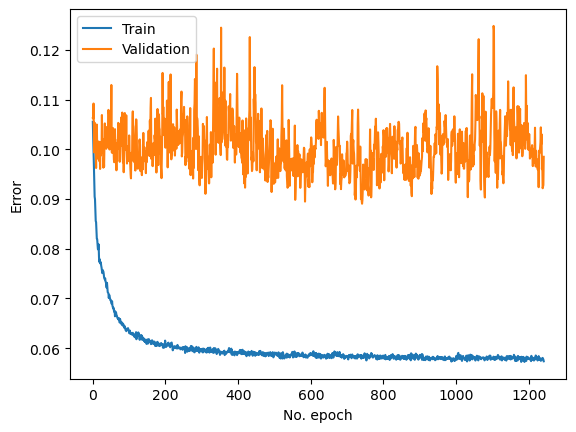

In [45]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### 2nd Fold

In [73]:
result = model.evaluate(x_test, y_test)
fold_2 = result[0]
print(f"Fold 2 MAE: {fold_2}")

2/2 [==============================] - 0s 2ms/step - loss: 0.0877 - mean_absolute_percentage_error: 19.2911
Fold 2 MAE: 0.08770983666181564


In [74]:
model.save('BERT_2ndFold_MAE.keras')

### 3rd Fold

In [110]:
result = model.evaluate(x_test, y_test)
fold_3 = result[0]
print(f"Fold 3 MAE: {fold_3}")

2/2 [==============================] - 0s 2ms/step - loss: 0.0843 - mean_absolute_percentage_error: 17.8672
Fold 3 MAE: 0.08426927775144577


In [111]:
model.save('BERT_3rdFold_MAE.keras')

### 4th Fold

In [135]:
result = model.evaluate(x_test, y_test)
fold_4 = result[0]
print(f"Fold 4 MAE: {fold_4}")


2/2 [==============================] - 0s 4ms/step - loss: 0.0809 - mean_absolute_percentage_error: 17.7539
Fold 4 MAE: 0.08086610585451126


In [136]:
model.save('BERT_4thFold_MAE.keras')

## Other not good enough trials

### 2nd（lr = 0.05）

In [48]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 2ms/step - loss: 0.0955 - mean_absolute_percentage_error: 21.6025


[0.09546943753957748, 21.602460861206055]

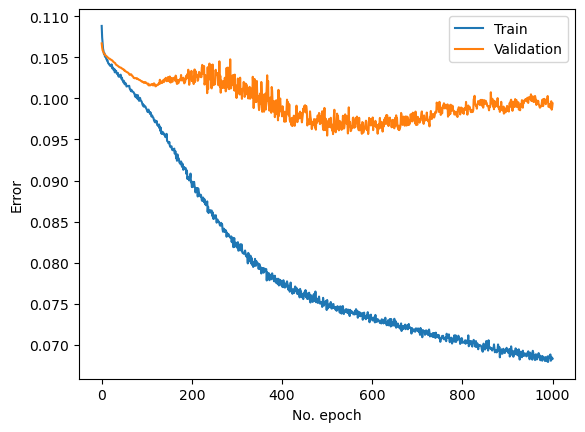

In [49]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### 3rd lr = 0.01

In [52]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 3ms/step - loss: 0.0934 - mean_absolute_percentage_error: 21.1740


[0.09339183568954468, 21.173969268798828]

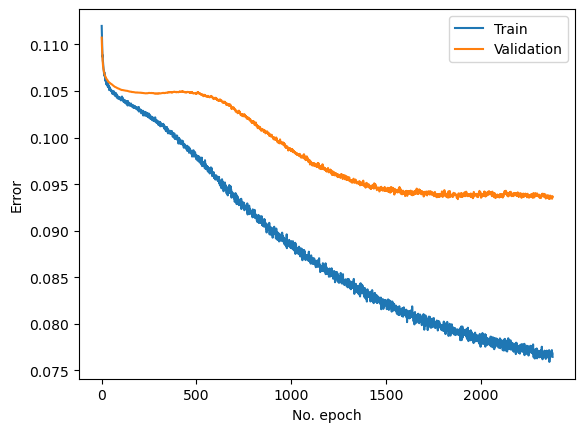

In [53]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### 4th improve dropout rate

In [57]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 2ms/step - loss: 0.0975 - mean_absolute_percentage_error: 21.9405


[0.09750325232744217, 21.94053077697754]

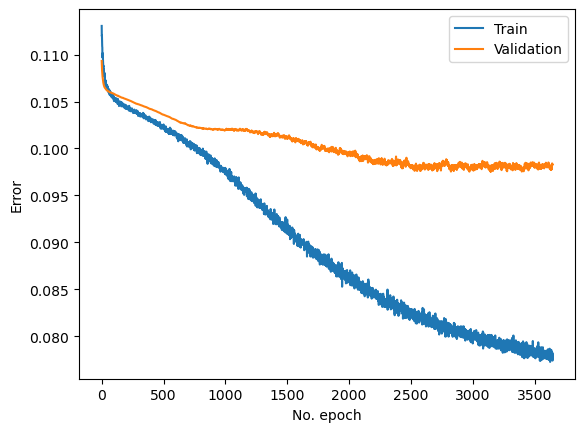

In [58]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### 5th adding layers，dropout back to 0.1

In [61]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 2ms/step - loss: 0.1004 - mean_absolute_percentage_error: 22.3488


[0.10038914531469345, 22.348773956298828]

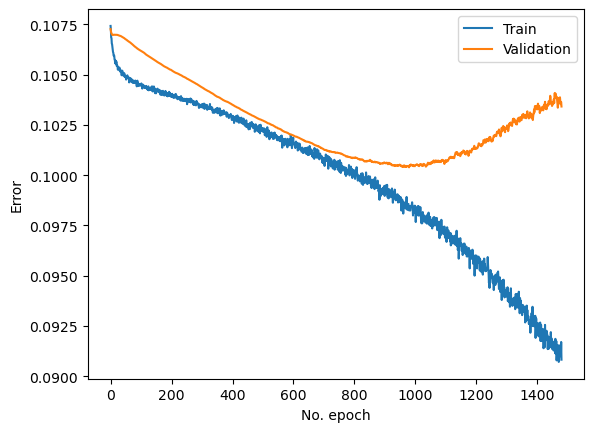

In [62]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### Remove 1 layer，and change to Adam optimizer，lr = 0.001 _**[best till now!]**_

In [66]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 3ms/step - loss: 0.0895 - mean_absolute_percentage_error: 20.5593


[0.08947484940290451, 20.559310913085938]

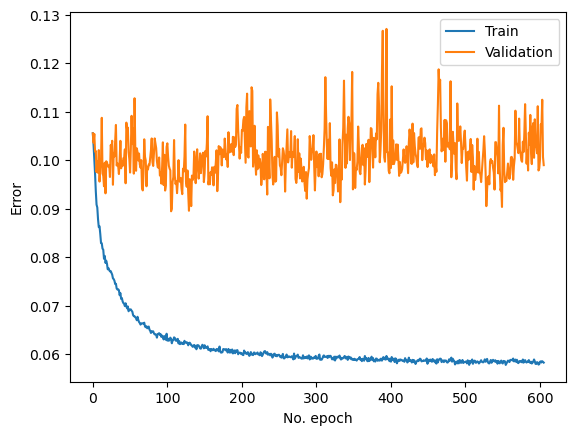

In [67]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

In [103]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 3ms/step - loss: 0.0890 - mean_absolute_percentage_error: 20.2119


[0.08901557326316833, 20.211856842041016]

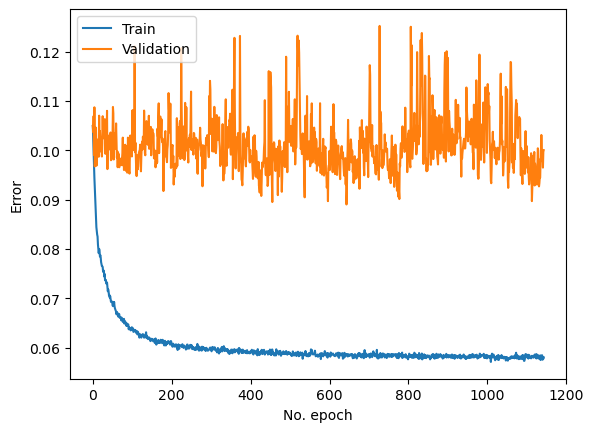

In [105]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### what about using lr schedule...

In [70]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 3ms/step - loss: 0.0918 - mean_absolute_percentage_error: 20.6962


[0.09180036187171936, 20.696205139160156]

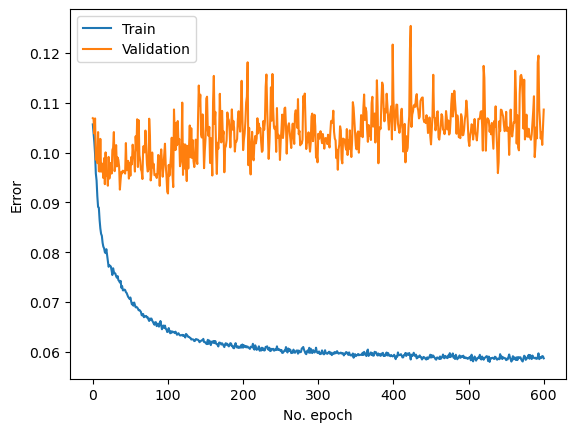

In [71]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### remove 3 templates...

In [134]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 3ms/step - loss: 0.0925 - mean_absolute_percentage_error: 21.2381


[0.0925462543964386, 21.23807144165039]

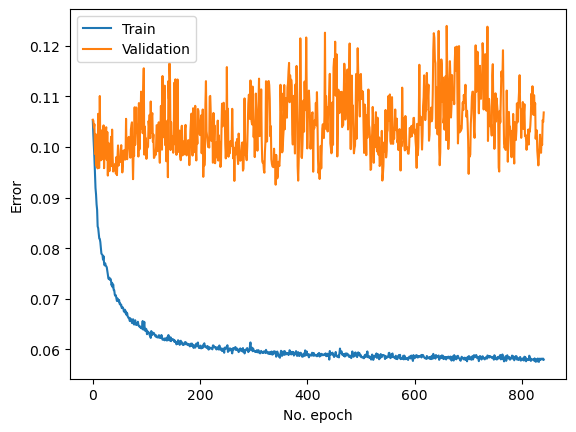

In [135]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### what about a cosine similarity loss function?..

In [187]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 4ms/step - loss: -0.9736 - mean_absolute_percentage_error: 22.8235


[-0.9735864400863647, 22.823543548583984]

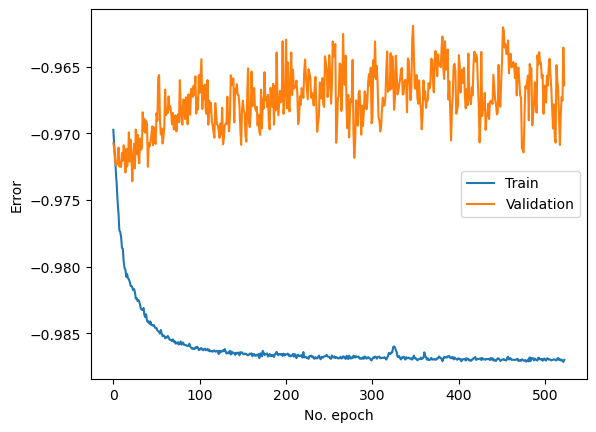

In [188]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

### Combine loss

In [209]:
model.evaluate(x_test, y_test)

2/2 [==============================] - 0s 3ms/step - loss: 0.0796 - mean_absolute_percentage_error: 21.0985 - mean_absolute_error: 0.0963


[0.0795917734503746, 21.098506927490234, 0.09628461301326752]

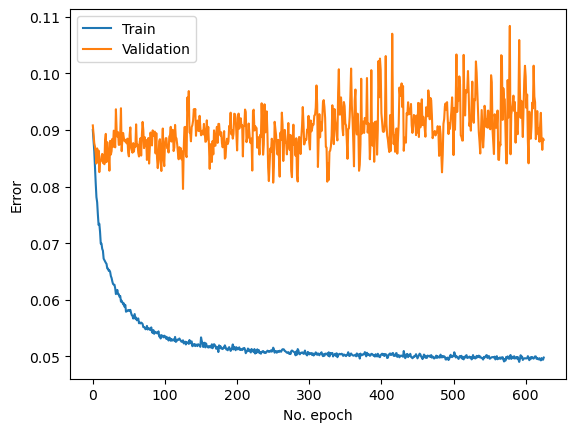

In [210]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.ylabel('Error')
plt.xlabel('No. epoch')
plt.legend()
plt.show()

In [46]:
model.save('BERT_FirstFold_MAE.keras')

## Now the best performance is 3 templates, 6 layers, with Adam optimizer, and MAE loss

In [ ]:
# do the four-fold cross validation to see the overall performance.
print(f"Fold 1 MAE: {fold_1}")
print(f"Fold 2 MAE: {fold_2}")
print(f"Fold 3 MAE: {fold_3}")
print(f"Fold 4 MAE: {fold_4}")

# 四折归一化 MAE 数值
fold_errors = np.array([
    fold_1,
    fold_2,
    fold_3,
    fold_4
])

# 转换至 dB 单位
errors_db = fold_errors * 8

# 计算均值和标准差
mean_db = errors_db.mean()
std_db = errors_db.std(ddof=0)  # 使用总体标准差
print(f"the mean absolute error in dB is {mean_db}, with a standard deviation of ±{std_db}")

Fold 1 MAE: 0.08906901627779007
Fold 2 MAE: 0.08770983666181564
Fold 3 MAE: 0.08426927775144577
Fold 4 MAE: 0.08086610585451126
the mean absolute error in dB is 0.6838284730911255, with a standard deviation of ±0.02548947033586596


In [4]:
0.08086610585451126*8

0.6469288468360901

# Testing

In [157]:
!pip install git+https://github.com/detly/gammatone.git

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
  Cloning https://github.com/detly/gammatone.git to /private/var/folders/sr/6_v8strs3_s6j1q05jw177qh0000gn/T/pip-req-build-0s2adbrs
  Running command git clone --filter=blob:none --quiet https://github.com/detly/gammatone.git /private/var/folders/sr/6_v8strs3_s6j1q05jw177qh0000gn/T/pip-req-build-0s2adbrs
  Resolved https://github.com/detly/gammatone.git to commit 0626328ef7c31d3b33214db2fdcd52e8601eb4c5
  Preparing metadata (setup.py) ... done


## Testing with audio files

In [9]:
from gammatone import filters 
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import soundfile as sf
import IPython.display

In [11]:
# Load and listen to original audio sample

x, fs = sf.read('signals/e_gtr_short.wav')
print(f"Loaded {x.shape[0]} samples at fs={fs}")
IPython.display.Audio(x,rate=fs)

Loaded 458317 samples at fs=44100


In [12]:
# Create filters
# - I have checked the center frequencies and implementation of the filters, and they all match up the same from the paper.
c_freqs = filters.centre_freqs(fs, 40, 20)
fcoefs = filters.make_erb_filters(fs, c_freqs, width=1.0)
# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
# Select a term (from the list above) and listen.
filterbank_x = filters.erb_filterbank(x, fcoefs)

In [162]:
test_word_set[2]

'sharp'

In [93]:
test_words = [ 'damage' ]            # 列表里只有 'crisp'
test_vec   = vec2(np.array(test_words)[:,None]).numpy()
#p          = model.predict(test_vec)         # 形状 (1,40)
test_vec

array([[1]])

In [95]:
test_words = 'bright'

test_vec   = compute_avg_vector(test_words,templates)

test_vec = test_vec.detach().cpu().numpy()   # 转换为 numpy 数组
test_vec.shape
test_vec = test_vec.reshape(1, -1)   
test_vec.shape


(768,)

1/1 [==============================] - 0s 37ms/step


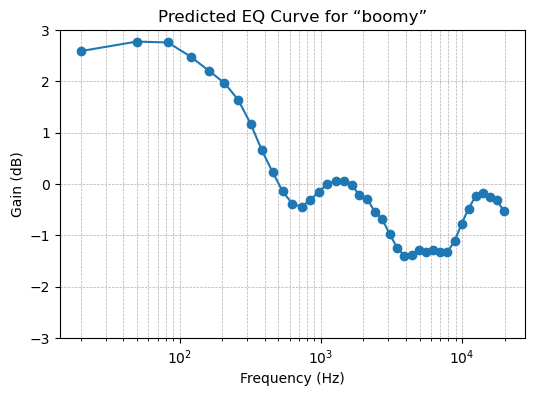

In [258]:

test_words = 'boomy'
test_model = keras.models.load_model('BERT_FourthFold_MAE.keras')
test_vec   = compute_avg_vector(test_words,templates)

test_vec = test_vec.detach().cpu().numpy()   # 转换为 numpy 数组
test_vec = test_vec.reshape(1, -1)            # 确保形状为 (1, 768)
p = test_model.predict(test_vec)

# y_test = (y_test - mmin) / (mmax - mmin)
p = p * (mmax - mmin) + mmin

# 假设 p 已经是反归一化后的预测结果，形状 (1,40)
gains_db = np.flip(1.5*p[0])  

# c_freqs 由你之前计算过
# c_freqs = filters.centre_freqs(fs, 40, 20)

plt.figure(figsize=(6,4))
plt.plot(c_freqs, gains_db, marker='o')      # 折线并在每个中心频率处画个点
plt.xscale('log')                             # 用对数坐标更符合听感
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain (dB)')
plt.ylim(-3.0, +3.0)
plt.title(f"Predicted EQ Curve for “{test_words}”")
plt.grid(True, which='both', ls='--', lw=0.5)
plt.show()

# Apply filterbank to audio signal and apply a given gain waiting value  to each band.
# Select a term (from the list above) and listen.
filterbank_x = filters.erb_filterbank(x, fcoefs)
out = np.sum(filterbank_x.T * np.flip(1.5*p[0, :]),axis=1)
IPython.display.Audio(out,rate=fs)

1/1 [==============================] - 0s 11ms/step


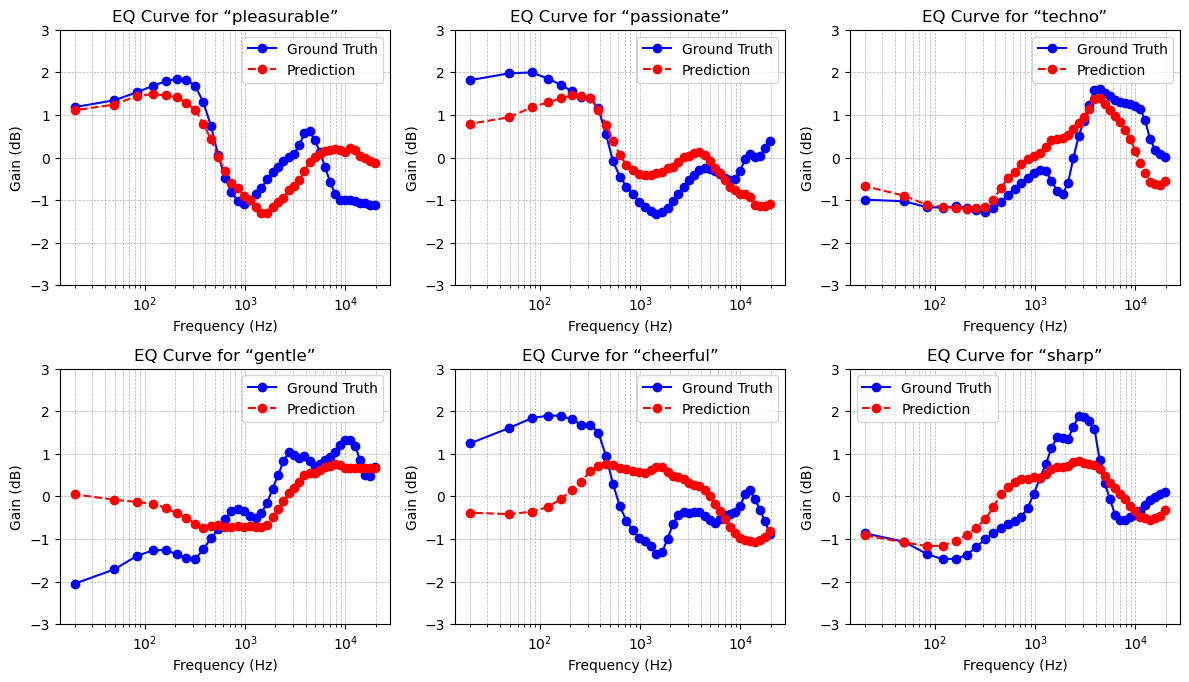

In [193]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

test_model = keras.models.load_model('BERT_FourthFold_MAE.keras')

# 固定随机种子以便重现结果
np.random.seed(78)

# 假设 test_samples 为测试词列表，y_test 为真实的 EQ 曲线（归一化后），


# 加载中心频率数组（假设已定义采样率 fs 和相关参数）
# 例如: c_freqs = filters.centre_freqs(fs, 40, 20)
# 这里假设 c_freqs 已经存在

# 随机抽取
num_curve = 6

selected_words = np.random.choice(test_word_set, num_curve, replace=False)

# 创建图形窗口，分成2x2子图显示每个抽样词的对比情况
plt.figure(figsize=(12, 20))

for i, word in enumerate(selected_words):
    indices = [idx for idx, w in enumerate(test_samples) if w == word]
    # 如果存在多个索引，随机选择一个
    selected_idx = random.choice(indices)
    
    # 利用模型获取预测曲线
    test_vec = compute_avg_vector(word, templates)
    # 将 PyTorch Tensor 转换为 numpy 数组，并重塑成 (1, 768)
    test_vec = test_vec.detach().cpu().numpy().reshape(1, -1)
    pred = test_model.predict(test_vec)
    # 反归一化：预测结果 p 是归一化后的 (0,1) 值，转换回原始 dB 值
    pred = pred * (mmax - mmin) + mmin  
    # 按频率顺序（例如从低到高）通常需要翻转
    pred_curve = np.flip(pred[0])
    
    # 获取对应的真实 EQ 曲线（假定 y_test 已经和 test_samples 对应且为归一化数据）
    gt_curve = y_test[selected_idx]
    # 反归一化真实曲线
    gt_curve = gt_curve * (mmax - mmin) + mmin
    gt_curve = np.flip(gt_curve)
    
    # 在子图中作图
    plt.subplot(num_curve,int(num_curve/2), i+1)
    plt.plot(c_freqs, gt_curve, 'b-o', label='Ground Truth')
    plt.plot(c_freqs, pred_curve, 'r--o', label='Prediction')
    plt.xscale('log')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Gain (dB)')
    plt.ylim(-3.0, +3.0)
    plt.title(f"EQ Curve for “{word}”")
    plt.legend()
    plt.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 10ms/step


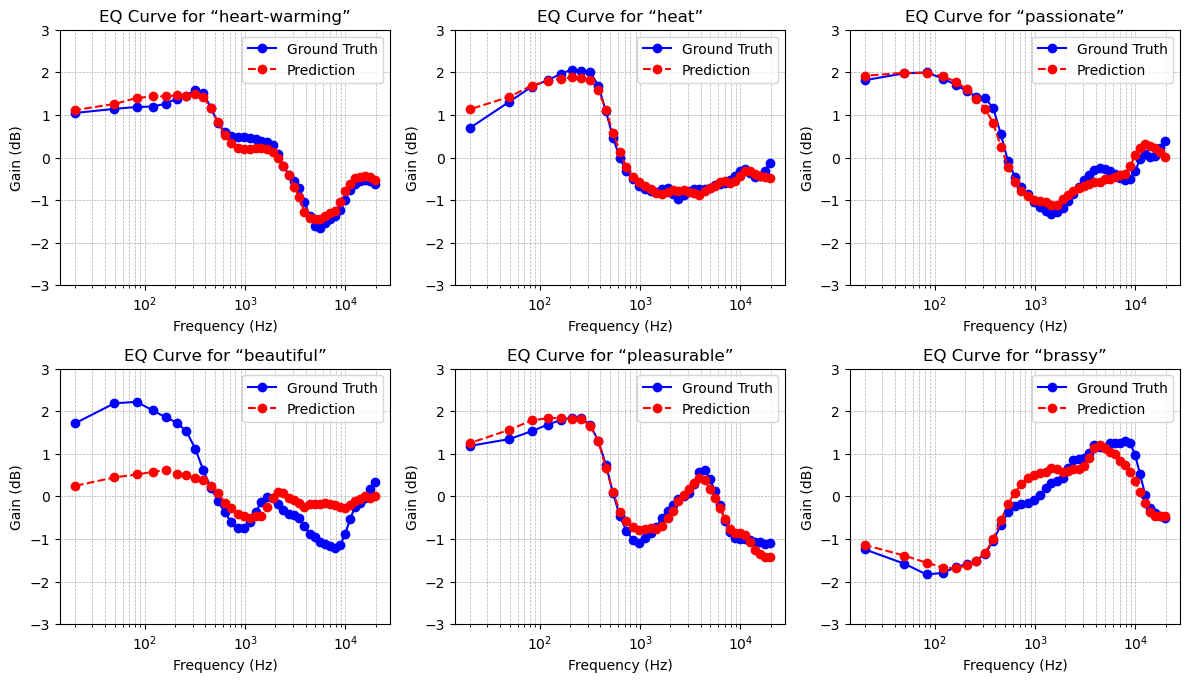

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

test_model = keras.models.load_model('BERT_FirstFold_combine2.keras',
                                     custom_objects={'combined_loss': combined_loss})

# 固定随机种子以便重现结果
np.random.seed(29)

# 假设 test_samples 为测试词列表，y_test 为真实的 EQ 曲线（归一化后），


# 加载中心频率数组（假设已定义采样率 fs 和相关参数）
# 例如: c_freqs = filters.centre_freqs(fs, 40, 20)
# 这里假设 c_freqs 已经存在

# 随机抽取
num_curve = 6

selected_words = np.random.choice(test_word_set, num_curve, replace=False)

# 创建图形窗口，分成2x2子图显示每个抽样词的对比情况
plt.figure(figsize=(12, 20))

for i, word in enumerate(selected_words):
    indices = [idx for idx, w in enumerate(test_samples) if w == word]
    # 如果存在多个索引，随机选择一个
    selected_idx = random.choice(indices)
    
    # 利用模型获取预测曲线
    test_vec = compute_avg_vector(word, templates)
    # 将 PyTorch Tensor 转换为 numpy 数组，并重塑成 (1, 768)
    test_vec = test_vec.detach().cpu().numpy().reshape(1, -1)
    pred = test_model.predict(test_vec)
    # 反归一化：预测结果 p 是归一化后的 (0,1) 值，转换回原始 dB 值
    pred = pred * (mmax - mmin) + mmin  
    # 按频率顺序（例如从低到高）通常需要翻转
    pred_curve = np.flip(pred[0])
    
    # 获取对应的真实 EQ 曲线（假定 y_test 已经和 test_samples 对应且为归一化数据）
    gt_curve = y_test[selected_idx]
    # 反归一化真实曲线
    gt_curve = gt_curve * (mmax - mmin) + mmin
    gt_curve = np.flip(gt_curve)
    
    # 在子图中作图
    plt.subplot(num_curve,int(num_curve/2), i+1)
    plt.plot(c_freqs, gt_curve, 'b-o', label='Ground Truth')
    plt.plot(c_freqs, pred_curve, 'r--o', label='Prediction')
    plt.xscale('log')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Gain (dB)')
    plt.ylim(-3.0, +3.0)
    plt.title(f"EQ Curve for “{word}”")
    plt.legend()
    plt.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.show()

# PCM

In [160]:
conf_events = [e for e in events[1:] if e[1] == "English" and float(e[3]) > 0.7 and e[0].lower() in test_word_set_3]
events_by_word = {}
for e in conf_events:
  e[0] = e[0].lower()

for e in conf_events:
  if e[0] in events_by_word.keys():
    ee = events_by_word[e[0]]
    ef = np.expand_dims(np.array(e[4:], dtype='float'), axis=0)
    events_by_word[e[0]] = np.append(ee, ef, axis=-2)
  else:
    events_by_word[e[0]] = np.zeros((1, 40))
    events_by_word[e[0]][0, :] = np.array(e[4:], dtype='float')

events_by_word_2 = {}
for k in events_by_word:
  if events_by_word[k].shape[0] > 1:
    events_by_word_2[k] = np.copy(events_by_word[k])


In [161]:
len(events_by_word_2)

8

In [162]:
events_by_word_2.keys()

dict_keys(['hot', 'deep', 'light', 'crisp', 'calm', 'cold', 'quiet', 'happy'])

In [163]:
double_word_set = set(events_by_word_2.keys())

In [154]:
means_by_word_1 = {}
for k in events_by_word_2.keys():
  means_by_word_1[k] = np.mean(events_by_word_2[k], axis=0, keepdims=True)

In [159]:
means_by_word_2 = {}
for k in events_by_word_2.keys():
  means_by_word_2[k] = np.mean(events_by_word_2[k], axis=0, keepdims=True)

In [164]:
means_by_word_3 = {}
for k in events_by_word_2.keys():
  means_by_word_3[k] = np.mean(events_by_word_2[k], axis=0, keepdims=True)

In [149]:
means_by_word_4 = {}
for k in events_by_word_2.keys():
  means_by_word_4[k] = np.mean(events_by_word_2[k], axis=0, keepdims=True)

In [166]:
means_by_word_1

{'warm': array([[ 1.17390281,  1.26399407,  1.36031638,  1.35505164,  1.29493971,
          1.19015198,  1.07752198,  1.00471672,  0.81906585,  0.47675493,
          0.10886236, -0.14648507, -0.31480994, -0.43719715, -0.54355136,
         -0.63607095, -0.74904219, -0.85661376, -0.83221398, -0.72345286,
         -0.63329252, -0.58694556, -0.59273369, -0.60649291, -0.527456  ,
         -0.35841661, -0.22753492, -0.18435741, -0.17359213, -0.15214835,
         -0.15334646, -0.16347434, -0.14024793, -0.09335311, -0.05137903,
         -0.06361162, -0.15982196, -0.25879991, -0.34494981, -0.4138869 ]]),
 'loud': array([[ 0.17616036,  0.26277374,  0.33522943,  0.40701073,  0.53876357,
          0.75340761,  0.96565611,  1.15229674,  1.21719808,  1.12472391,
          0.97837465,  0.83781765,  0.72375777,  0.66734375,  0.69331022,
          0.71329502,  0.72299397,  0.69090663,  0.57899385,  0.43490792,
          0.28235528,  0.14309868,  0.03555317, -0.10037445, -0.28864914,
         -0.5055258

In [165]:
means_by_word_4

{'warm': array([[ 1.17390281,  1.26399407,  1.36031638,  1.35505164,  1.29493971,
          1.19015198,  1.07752198,  1.00471672,  0.81906585,  0.47675493,
          0.10886236, -0.14648507, -0.31480994, -0.43719715, -0.54355136,
         -0.63607095, -0.74904219, -0.85661376, -0.83221398, -0.72345286,
         -0.63329252, -0.58694556, -0.59273369, -0.60649291, -0.527456  ,
         -0.35841661, -0.22753492, -0.18435741, -0.17359213, -0.15214835,
         -0.15334646, -0.16347434, -0.14024793, -0.09335311, -0.05137903,
         -0.06361162, -0.15982196, -0.25879991, -0.34494981, -0.4138869 ]]),
 'heavy': array([[ 1.59080748,  1.81041188,  1.98610911,  1.94225371,  1.84551785,
          1.75813594,  1.63290644,  1.42197319,  0.97717415,  0.47233281,
          0.04211884, -0.30472033, -0.5547826 , -0.67733596, -0.68516431,
         -0.5946857 , -0.55921279, -0.55150965, -0.48775668, -0.39764404,
         -0.34105627, -0.33080743, -0.33519647, -0.39686232, -0.53906527,
         -0.770755

In [ ]:
error_by_word = {}
dev_error_by_word = {}

In [141]:
test_events = [e for e in events[1:] if e[1] == "English" and e[0].lower() in test_word_set_4 and float(e[3]) > 0.7 and e[0].lower() in double_word_set]

In [142]:
test_events

[['warm',
  'English',
  '8',
  '0.806225',
  '1.9701525217517495',
  '2.063643882976158',
  '2.1096215031172827',
  '2.0190630886253356',
  '1.8335571531272534',
  '1.5405025703436457',
  '1.2537910386852604',
  '1.124354285337375',
  '0.9121204679212922',
  '0.4799170362033015',
  '-0.17676768336628335',
  '-0.7665481006084572',
  '-0.9822884117425815',
  '-0.8764766034472634',
  '-0.8714837148909533',
  '-0.9865919838879997',
  '-1.0953732685691253',
  '-1.0060183246829977',
  '-0.6653072707699701',
  '-0.3864144790135681',
  '-0.2823194761612249',
  '-0.23648025284502341',
  '-0.18285213527830987',
  '-0.09432834455845615',
  '0.11566499326724095',
  '0.429528178399535',
  '0.44320781941462645',
  '0.2255928159181241',
  '-0.06147435852460424',
  '-0.4354099027145549',
  '-0.8661044535730853',
  '-1.0935069219305404',
  '-1.0488729222449595',
  '-0.8384336166990671',
  '-0.6501905540656232',
  '-0.5673330944619641',
  '-0.6661827535827004',
  '-0.7608213581668304',
  '-0.6223403053

In [49]:
#!pip install similaritymeasures
import similaritymeasures


In [143]:
model = keras.models.load_model('BERT_4thFold_MAE.keras')
BERT_areas = []

for e in test_events:
  x = np.arange(0, 40, 1)
  test_words = e[0].lower()
  test_vec = compute_avg_vector(test_words, templates)
  # 将 PyTorch Tensor 转换为 numpy 数组，并重塑成 (1, 768)
  test_vec = test_vec.detach().cpu().numpy().reshape(1, -1)
  pred = model.predict(test_vec)
    
  y = pred[0, :] * (mmax - mmin) + mmin 
  
  exp_data = np.zeros((40, 2))
  exp_data[:, 0] = x
  exp_data[:, 1] = y

  x_hat = np.arange(0, 40, 1)
  y_hat = np.array(e[4:], dtype='float')
  num_data = np.zeros((40, 2))
  num_data[:, 0] = x_hat
  num_data[:, 1] = y_hat


  area = similaritymeasures.pcm(exp_data, num_data)
  BERT_areas.append(area)


1/1 [==============================] - 0s 10ms/step


In [86]:
pcm_Fold1 = np.mean(BERT_areas)
print(f"Fold 1 PCM: {pcm_Fold1}")

Fold 1 PCM: 5.248332743498021


In [96]:
pcm_Fold2 = np.mean(BERT_areas)
print(f"Fold 2 PCM: {pcm_Fold2}")

Fold 2 PCM: 6.18525539633489


In [119]:
pcm_Fold3 = np.mean(BERT_areas)
print(f"Fold 3 PCM: {pcm_Fold3}")

Fold 3 PCM: 5.199270091646541


In [144]:
pcm_Fold4 = np.mean(BERT_areas)
print(f"Fold 4 PCM: {pcm_Fold4}")

Fold 4 PCM: 4.950902128491435


In [146]:
PCM = np.mean([pcm_Fold1, pcm_Fold2, pcm_Fold3, pcm_Fold4])
print(f"The average PCM across all 4 folds is {PCM}")

The average PCM across all 4 folds is 5.395940089992722


# Semantic Plots

In [169]:
means_by_word_3

{'hot': array([[-0.27808462, -0.49932441, -0.5595022 , -0.5369213 , -0.50372234,
         -0.4215006 , -0.17829864,  0.32730868,  0.93719011,  1.31891697,
          1.47985389,  1.54478329,  1.55426012,  1.54910454,  1.51404112,
          1.42649192,  1.39234586,  1.28002319,  0.93461737,  0.50489337,
          0.07292521, -0.25157396, -0.46297805, -0.55028865, -0.67549582,
         -0.85572882, -0.83849313, -0.62164423, -0.46376337, -0.46739893,
         -0.55290062, -0.68434427, -0.77533698, -0.77800129, -0.74031377,
         -0.74189561, -0.7507783 , -0.82991476, -0.91554101, -0.90300995]]),
 'deep': array([[ 1.46782448,  1.73575506,  1.90397875,  1.88079458,  1.78703589,
          1.6420377 ,  1.45651998,  1.25848838,  0.91451354,  0.52213933,
          0.17567547, -0.08451721, -0.3038569 , -0.46376563, -0.54609268,
         -0.59721573, -0.71971167, -0.82314107, -0.76215644, -0.60722792,
         -0.48600861, -0.44768885, -0.50676288, -0.65066191, -0.78423483,
         -0.82758065

Counts per fold: 3 12 8 4


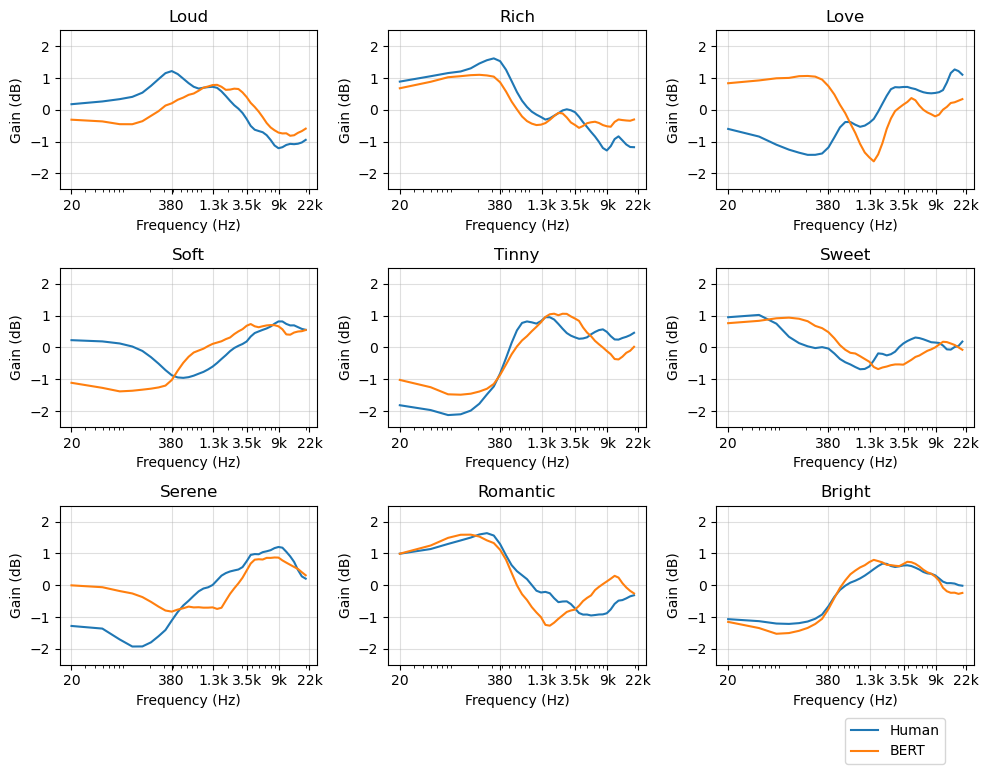

Saved: ./semantic_plots_page_1.pdf


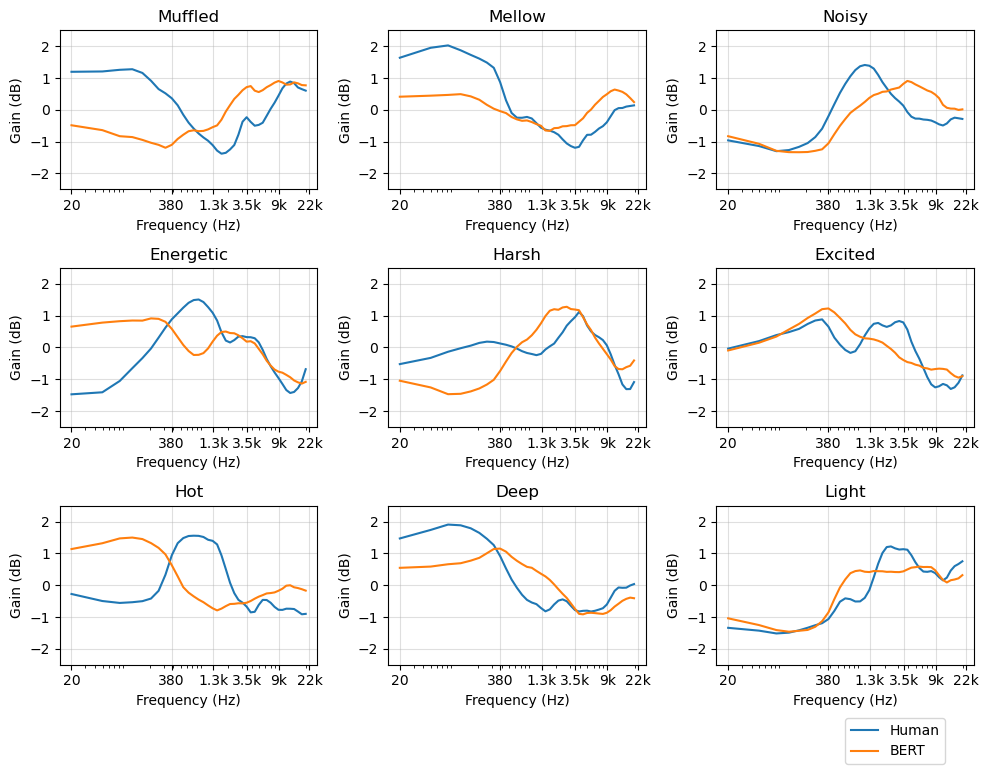

Saved: ./semantic_plots_page_2.pdf


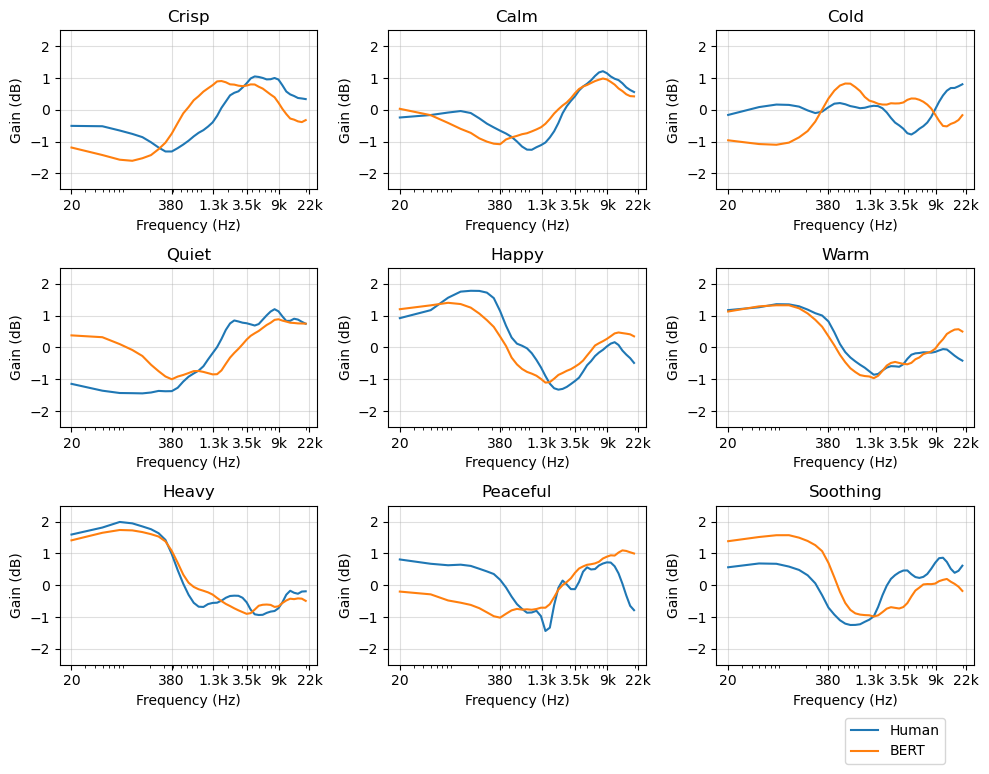

Saved: ./semantic_plots_page_3.pdf


In [190]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import random

# ==== 必要前置：请确保这几个对象已就绪 ====
# means_by_word_1, means_by_word_2, means_by_word_3, means_by_word_4  # dict: word -> (1,40) or (40,)
model_f1 = keras.models.load_model('BERT_FirstFold_MAE.keras')
model_f2 = keras.models.load_model('BERT_2ndFold_MAE.keras')
model_f3 = keras.models.load_model('BERT_3rdFold_MAE.keras')
model_f4 = keras.models.load_model('BERT_4thFold_MAE.keras')
# compute_avg_vector(word, templates)   # -> torch.Tensor shape (hidden,)
# mmin, mmax                            # 训练时用于反归一化的同一组参数（标量或 shape=(40,)）
# freq_labels                           # 如无则会用兜底
freq_labels = ["20", "380", "1.3k", "3.5k", "9k", "22k"]

# 兜底频率刻度标签（如果你没定义 freq_labels）
try:
    _ = freq_labels
except NameError:
    freq_labels = ['20', '100', '500', '2k', '8k', '20k']

# —— 小工具：取 numpy 曲线，保证 shape=(40,)；可按需翻转到“低→高”频段 ——
def _to_curve_40(x, flip=False):
    x = np.asarray(x, dtype=float)
    if x.ndim == 2 and x.shape[0] == 1:
        x = x[0]
    if flip:
        x = np.flip(x)
    assert x.shape[0] == 40, f"curve length != 40, got {x.shape}"
    return x

def _predict_curve(model, word, templates, mmin, mmax, flip=False):
    # 与训练完全一致的向量化
    vec = compute_avg_vector(word, templates)           # torch tensor
    vec = vec.detach().cpu().numpy().reshape(1, -1).astype('float32')
    pred = model.predict(vec, verbose=0)                # (1,40) or (40,)
    pred = np.asarray(pred, dtype=float)
    # 反归一化（mmin/mmax 可以是标量或(40,)，需与训练一致）
    pred = pred * (mmax - mmin) + mmin
    return _to_curve_40(pred, flip=flip)

# —— 准备四个 fold 的“人类均值曲线”与模型映射（去掉 fold1 的 warm） ——
# 统一小写键名，避免大小写问题
def _lower_keys(d):
    return {k.lower(): _to_curve_40(v, flip=False) for k, v in d.items()}

mbw1 = _lower_keys(means_by_word_1)
mbw2 = _lower_keys(means_by_word_2)
mbw3 = _lower_keys(means_by_word_3)
mbw4 = _lower_keys(means_by_word_4)

# 指定要从 fold1 移除的重复词（小写）
remove_from_fold1 = {'warm'}

for w in list(mbw1.keys()):
    if w in remove_from_fold1:
        mbw1.pop(w, None)

# 统计数量（应为 4,12,8,4 → 去掉 warm 后总计 27）
print("Counts per fold:", len(mbw1), len(mbw2), len(mbw3), len(mbw4))

# fold -> (human_dict, model)
folds = [
    ('Fold 1', mbw1, model_f1),
    ('Fold 2', mbw2, model_f2),
    ('Fold 3', mbw3, model_f3),
    ('Fold 4', mbw4, model_f4),
]

# —— 汇总 27 个词，记录每个词属于哪个 fold，以便用对应模型预测 ——
ordered_words = []
word2foldix = {}
for fi, (_, human_dict, _) in enumerate(folds):
    for w in human_dict.keys():
        ordered_words.append(w)
        word2foldix[w] = fi

# 可选：如果你想固定展示顺序，也可以在这里自定义 ordered_words 的排序
# random.shuffle(ordered_words)  # 如需随机

# —— 逐词生成：Human 均值曲线 & 模型预测曲线 ——
# 是否翻转到“低→高”频段显示（你自己的代码常用 flip）
DO_FLIP = True

human_labels = {}
model_preds  = {}
for w in ordered_words:
    fi = word2foldix[w]
    fold_name, human_dict, model = folds[fi]
    human_labels[w] = _to_curve_40(human_dict[w], flip=DO_FLIP)
    model_preds[w]  = _predict_curve(model, w, templates, mmin, mmax, flip=DO_FLIP)

# —— 画三张 3×3 图，每张 9 个词 ——
rows, cols = 3, 3
per_fig = rows * cols
total = len(ordered_words)
num_figs = int(np.ceil(total / per_fig))

def _page_words(words, page, size):
    s = page * size
    return words[s:s+size]

# # x 轴用于绘线（只是索引；刻度标签用 freq_labels）
# x_idx = np.arange(40)

# for page in range(num_figs):
#     words_this = _page_words(ordered_words, page, per_fig)
#     plt.figure(figsize=(10.0, 8.0))

#     for i, w in enumerate(words_this):
#         plt.subplot(rows, cols, i+1)
#         # plt.plot(human_labels[w], label="Human")
#         # plt.plot(model_preds[w],  label=f"Model ({['F1','F2','F3','F4'][word2foldix[w]]})")
#         plt.title(w.capitalize())

#         # 与原作者风格一致的刻度与外观
        
#         plt.plot(c_freqs, human_labels[w], label="Human")
#         plt.plot(c_freqs, model_preds[w],  label="Model")
#         plt.xscale("log")  # 可选，常见的频率轴是对数坐标
#         plt.xticks([20, 380, 1300, 3500, 9000, 22000], labels=freq_labels)
#         #plt.xticks(ticks=[0, 8, 16, 24, 32, 40], labels=freq_labels)
#         plt.xlabel("Frequency (Hz)")
#         plt.grid(visible=True, axis='both', which='major', alpha=0.4)
#         plt.ylim((-2.5, +2.5))
#         plt.ylabel("Gain (dB)")

#     # 统一图例放在底部
#     # handles, labels = plt.gca().get_legend_handles_labels()
#     # plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2)
#     # plt.tight_layout()

#     # out_path = f"./semantic_plots_page_{page+1}.pdf"
#     # plt.savefig(out_path, format='pdf', bbox_inches='tight')
#     # plt.show()
#     # print(f"Saved: {out_path}")
#     handles, labels = [], []
#     for ax in axes:
#         h, l = ax.get_legend_handles_labels()
#         handles += h; labels += l
#     uniq = dict(zip(labels, handles))  # 后面的覆盖前面的，完成去重

#     # 放在图外底部居中；ncol 可按需调为 2 或 3
#     fig.legend(uniq.values(), uniq.keys(),
#                loc='lower center', bbox_to_anchor=(0.5, 0.005),
#                ncol=2, frameon=False)

#     # 给底部图例留空间：rect 的下边界 0.08~0.12 视具体内容微调
#     fig.tight_layout(rect=[0, 0.08, 1, 1])

#     out_path = f"./semantic_plots_page_{page+1}.pdf"
#     fig.savefig(out_path, format='pdf', bbox_inches='tight')
#     plt.show()
#     print(f"Saved: {out_path}")

# —— 检查与兜底 —— 
# c_freqs = np.asarray(c_freqs, dtype=float)
# assert c_freqs.shape[0] == 40, f"c_freqs 长度应为 40，当前 {c_freqs.shape}"
# # 若需要：确保频率从低到高递增（你前面若已 flip 到“低→高”就不用这句）
# # assert np.all(np.diff(c_freqs) > 0), "c_freqs 应严格递增"

# 频率刻度（可按需要改）
x_ticks = [20, 380, 1300, 3500, 9000, 22000]
assert len(freq_labels) == len(x_ticks), "freq_labels 数量需与 x_ticks 一致"

rows, cols = 3, 3
per_fig = rows * cols

def _page_words(words, page, size):
    s = page * size
    return words[s:s+size]

for page in range(num_figs):
    words_this = _page_words(ordered_words, page, per_fig)

    # 正方形画布
    fig = plt.figure(figsize=(10, 8))
    axes = []  # 收集子图用于统一图例

    for i, w in enumerate(words_this):
        ax = fig.add_subplot(rows, cols, i + 1)
        axes.append(ax)

        # 画曲线：Human vs 对应 fold 的 Model 预测
        ax.plot(c_freqs, human_labels[w], label="Human")
        ax.plot(c_freqs, model_preds[w],  label=f"BERT")

        # 外观设定
        ax.set_title(w.capitalize())
        ax.set_xscale("log")                       # 频率用对数坐标更符合习惯
        #ax.set_xlim(c_freqs.min(), c_freqs.max())
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(freq_labels)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Gain (dB)")
        ax.set_ylim(-2.5, 2.5)
        ax.grid(True, axis='both', which='major', alpha=0.4)

    # —— 整图级图例（放在图外底部，且不与任何子图重叠）——
    handles_all, labels_all = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles_all += h; labels_all += l
    uniq = dict(zip(labels_all, handles_all))  # 去重（后者覆盖前者）

    fig.legend(uniq.values(), uniq.keys(),
               loc='lower center', bbox_to_anchor=(0.9, 0.03),
               )

    # 给底部图例预留空间；可在 0.06~0.12 间微调
    fig.tight_layout(rect=[0, 0.09, 1, 1])

    out_path = f"./semantic_plots_page_{page+1}.pdf"
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"Saved: {out_path}")

Saved: ./semantic_pair_fold4_muffled_underwater.pdf


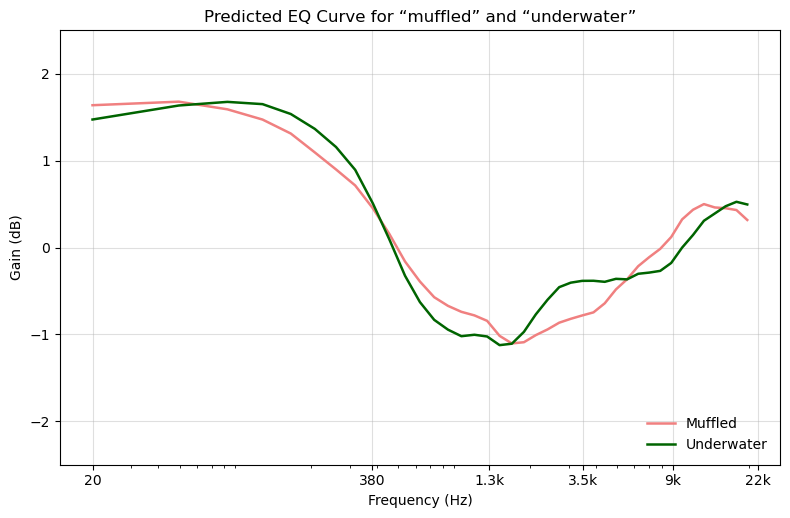

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 依赖的已有对象（请确保在你的环境中已定义）：
# - model_f4: keras.models.load_model('BERT_4thFold_MAE.keras') 的返回
model_f4 = keras.models.load_model('BERT_4thFold_MAE.keras', compile=False)
# - compute_avg_vector(word, templates)
# - templates
# - mmin, mmax  (与训练一致的反归一化参数；可为标量或 shape=(40,))
# - c_freqs     (长度为40的频率中心数组；与曲线一一对应)
# - freq_labels 与 x_ticks（若未定义，会使用兜底）

# 兜底：频率刻度与标签（若未在上文定义）
if 'freq_labels' not in globals():
    freq_labels = ["20", "380", "1.3k", "3.5k", "9k", "22k"]
if 'x_ticks' not in globals():
    x_ticks = [20, 380, 1300, 3500, 9000, 22000]

def _predict_curve_fold4(word, flip=True):
    """使用第四折模型对单词做预测，返回 shape=(40,) 的曲线（可选翻转为低->高）。"""
    vec = compute_avg_vector(word, templates)           # torch.Tensor
    vec = vec.detach().cpu().numpy().reshape(1, -1).astype('float32')
    pred = model_f4.predict(vec, verbose=0)             # (1,40) 或 (40,)
    pred = np.asarray(pred, dtype=float).squeeze()
    # 反归一化（与训练一致）
    pred = pred * (mmax - mmin) + mmin
    pred = np.asarray(pred, dtype=float).reshape(-1)
    assert pred.shape[0] == 40, f"预测曲线长度应为40，得到 {pred.shape}"
    if flip:
        pred = pred[::-1]
    return pred

def plot_two_words_fold4(word_a, word_b, flip=True, save_dir="./", fname=None):
    """
    用第四折模型在同一坐标系中绘制两个词的预测曲线：
    - word_a: 红色
    - word_b: 绿色
    轴样式与你上面的代码保持一致，并保存为 PDF。
    """
    # 频率轴准备
    assert 'c_freqs' in globals(), "请先定义 c_freqs（与40段曲线对应的中心频率，长度=40）"
    cf = np.asarray(c_freqs, dtype=float)
    assert cf.shape[0] == 40, f"c_freqs 长度应为40，当前 {cf.shape}"

    # 如果曲线翻转为“低->高”，而 c_freqs 当前是“高->低”，则也翻转 c_freqs，保持对齐
    # if flip and not np.all(np.diff(cf) > 0):
    #     cf = cf[::-1]

    # 模型预测
    y_red   = _predict_curve_fold4(word_a, flip=flip)
    y_green = _predict_curve_fold4(word_b, flip=flip)

    # 画图
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(cf, y_red,   label=word_a.capitalize(), color='lightcoral',   linewidth=1.8)
    ax.plot(cf, y_green, label=word_b.capitalize(), color='darkgreen', linewidth=1.8)

    # 轴外观：与上文保持一致
    ax.set_title(f"Predicted EQ Curve for “{word_a}” and “{word_b}”")
    ax.set_xscale("log")
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(freq_labels)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Gain (dB)")
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, axis='both', which='major', alpha=0.4)

    # 底部居中图例，并为其留出空间
    ax.legend(loc='lower right', ncol=1, frameon=False)
    fig.tight_layout(rect=[0, 0.12, 1, 1])

    # 保存 PDF
    if fname is None:
        def _safe(s): return "".join(ch if ch.isalnum() or ch in ('-','_') else '_' for ch in s)
        fname = f"semantic_pair_fold4_{_safe(word_a)}_{_safe(word_b)}.pdf"
    out_path = os.path.join(save_dir, fname)
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()

# --- 使用示例 ---
plot_two_words_fold4("muffled", "underwater", flip=True)

Saved: ./semantic_pair_fold4_warm_extra_warm.pdf


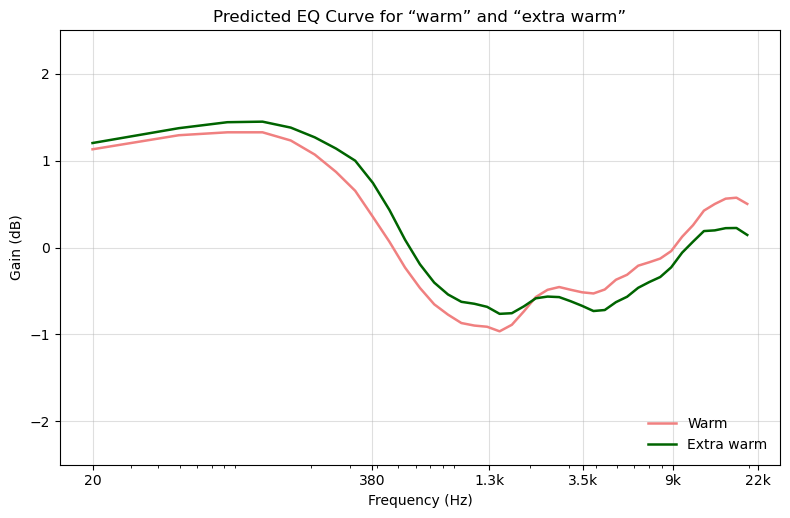

In [ ]:
plot_two_words_fold4("", "extra warm", flip=True)

In [28]:
def plot_four_pairs_fold4(pairs, flip=True, save_dir="./", fname="semantic_pairs_2x2.pdf"):
    """
    pairs: 长度为4的列表/元组，每个元素是 (word_a, word_b)
           例如：[("warm","hot"), ("bright","tinny"), ("muffled","underwater"), ("rich","romantic")]
    """
    # 频率轴
    assert 'c_freqs' in globals(), "请先定义 c_freqs（长度=40，对应40段频带中心频率）"
    cf = np.asarray(c_freqs, dtype=float)
    assert cf.shape[0] == 40, f"c_freqs 长度应为40，当前 {cf.shape}"

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()

    for i, (wa, wb) in enumerate(pairs):
        ax = axes[i]

        # 预测两条曲线
        y_red   = _predict_curve_fold4(wa, flip=flip)
        y_green = _predict_curve_fold4(wb, flip=flip)

        # 画曲线（浅红 / 深绿）
        ax.plot(cf, y_red,   label=wa.capitalize(), color='lightcoral', linewidth=1.8)
        ax.plot(cf, y_green, label=wb.capitalize(), color='darkgreen',  linewidth=1.8)

        # 坐标系外观（与现有保持一致）
        ax.set_title(f'“{wa}” vs “{wb}”')
        ax.set_xscale("log")
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(freq_labels)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Gain (dB)")
        ax.set_ylim(-2.5, 2.5)
        ax.grid(True, axis='both', which='major', alpha=0.4)

        # 每个子图右下角图例，竖排两行
        ax.legend(loc='lower right', ncol=1, frameon=False)

    fig.tight_layout(rect=[0, 0.02, 1, 1])

    # 保存整张大图
    def _safe(s): return "".join(ch if ch.isalnum() or ch in ('-','_') else '_' for ch in s)
    base = "_".join([f"{_safe(a)}-{_safe(b)}" for a, b in pairs])
    out_path = os.path.join(save_dir, fname if fname else f"semantic_pairs_2x2_{base}.pdf")
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()

Saved: ./semantic_pairs_2x2.pdf


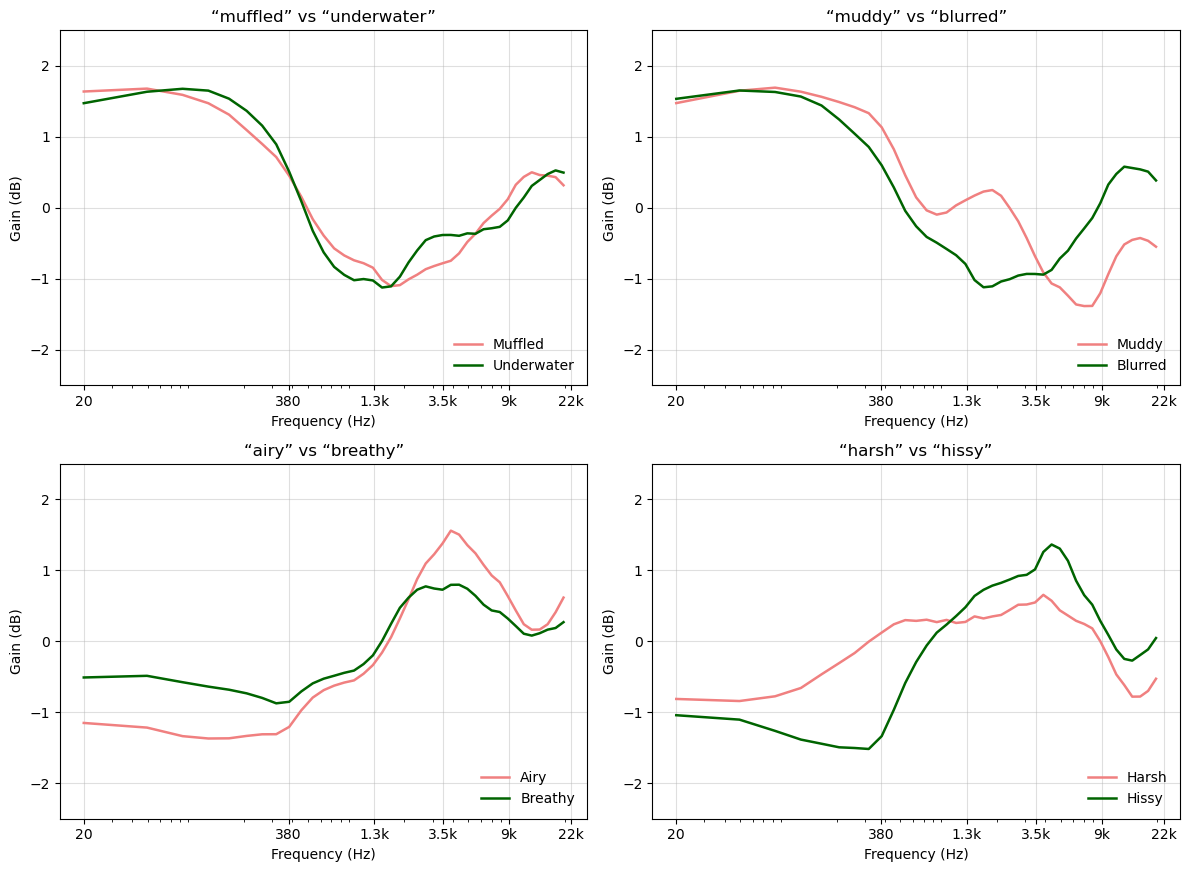

In [29]:
plot_four_pairs_fold4([
    ("muffled", "underwater"),
    ("muddy", "blurred"),
    ("airy", "breathy"),
    ("harsh", "hissy"),
], flip=True, fname="semantic_pairs_2x2.pdf")

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import similaritymeasures

model_f4 = keras.models.load_model('BERT_4thFold_MAE.keras', compile=False)

def compute_metrics(y1: np.ndarray, y2: np.ndarray, cf=None):
    """
    计算 MAE 与 PCM (使用 similaritymeasures.pcm)
    y1, y2: shape=(40,)
    cf: 对应频率坐标 (长度=40)，如果为 None 则自动用索引
    返回: mae(float), pcm(float)
    """
    y1 = np.asarray(y1, dtype=float).reshape(-1)
    y2 = np.asarray(y2, dtype=float).reshape(-1)
    assert y1.shape == y2.shape, f"Shape mismatch: {y1.shape} vs {y2.shape}"

    mae = np.mean(np.abs(y1 - y2))

    # --- 准备输入数据 (freq, gain)
    if cf is None:
        cf = np.arange(len(y1))
    exp_data = np.column_stack((cf, y1))
    num_data = np.column_stack((cf, y2))

    # PCM (Pathwise Curve Matching) 面积相似度，越小越相似
    area = similaritymeasures.pcm(exp_data, num_data)
    return float(mae), float(area)

def _fmt_metrics(mae, pcm):
    mae_s = f"MAE={mae:.3f} dB"
    pcm_s = f"PCM={pcm:.3f}"   # PCM 越小越相似
    return f"{mae_s}, {pcm_s}"
# ====== 2) 你已有的预测函数（保持不变） ======
# _predict_curve_fold4(word, flip=True)  <-- 用你现有的版本

# ====== 3) 两词对比图：加指标计算 & 可选标注 ======
def plot_two_words_fold4(word_a, word_b, flip=True, save_dir="./", fname=None,
                         annotate="title"):
    """
    annotate: None / "title" / "legend" / "text"
      - None: 不在图中写指标（推荐论文正式版，指标写图注或表格）
      - "title": 把 MAE/PCM 追加在标题
      - "legend": 把 MAE/PCM 写在图例中（会把两条label合并成一条描述）
      - "text": 在图内右上角放一段文字框
    """
    assert 'c_freqs' in globals(), "请定义 c_freqs，长度=40"
    cf = np.asarray(c_freqs, dtype=float)
    assert cf.shape[0] == 40

    y_red   = _predict_curve_fold4(word_a, flip=flip)
    y_green = _predict_curve_fold4(word_b, flip=flip)

    mae, pcm = compute_metrics(y_red, y_green)
    metrics_str = _fmt_metrics(mae, pcm)

    fig, ax = plt.subplots(figsize=(8, 6))
    l1, = ax.plot(cf, y_red,   label=word_a.capitalize(), color='lightcoral', linewidth=1.8)
    l2, = ax.plot(cf, y_green, label=word_b.capitalize(), color='darkgreen',  linewidth=1.8)

    title_base = f'Predicted EQ Curve: “{word_a}” vs “{word_b}”'
    if annotate == "title":
        ax.set_title(f"{title_base}  |  {metrics_str}")
    else:
        ax.set_title(title_base)

    ax.set_xscale("log")
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(freq_labels)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Gain (dB)")
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, axis='both', which='major', alpha=0.4)

    if annotate == "legend":
        # 合并信息到一条 legend（更紧凑）
        ax.legend([l1, l2], [f"{word_a.capitalize()} / {word_b.capitalize()}",
                             metrics_str], loc='lower right', frameon=False)
    else:
        ax.legend(loc='lower right', frameon=False)

    if annotate == "text":
        ax.text(0.98, 0.02, metrics_str,
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=10, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9))

    fig.tight_layout(rect=[0, 0.12, 1, 1])

    if fname is None:
        def _safe(s): return "".join(ch if ch.isalnum() or ch in ('-','_') else '_' for ch in s)
        fname = f"semantic_pair_fold4_{_safe(word_a)}_{_safe(word_b)}.pdf"
    out_path = os.path.join(save_dir, fname)
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {out_path}")
    plt.show()

    return {"pair": (word_a, word_b), "mae": mae, "pcm": pcm, "path": out_path}

# ====== 4) 2x2 四对图：加指标计算 & 导出CSV ======
def plot_four_pairs_fold4(pairs, flip=True, save_dir="./",
                          fname="semantic_pairs_2x2.pdf",
                          annotate="text",
                          csv_name="semantic_pairs_metrics.csv"):
    """
    pairs: [(word_a, word_b), ...] 长度=4
    annotate: None / "title" / "legend" / "text"
    额外输出：metrics CSV（列：pair, word_a, word_b, MAE, PCM）
    """
    assert 'c_freqs' in globals(), "请定义 c_freqs，长度=40"
    cf = np.asarray(c_freqs, dtype=float)
    assert cf.shape[0] == 40

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.ravel()
    rows = []  # 用来汇总导出CSV

    for i, (wa, wb) in enumerate(pairs):
        ax = axes[i]
        y_red   = _predict_curve_fold4(wa, flip=flip)
        y_green = _predict_curve_fold4(wb, flip=flip)
        mae, pcm = compute_metrics(y_red, y_green)
        metrics_str = _fmt_metrics(mae, pcm)

        ax.plot(cf, y_red,   label=wa.capitalize(), color='lightcoral', linewidth=1.8)
        ax.plot(cf, y_green, label=wb.capitalize(), color='darkgreen',  linewidth=1.8)

        title_base = f'“{wa}” vs “{wb}”'
        if annotate == "title":
            ax.set_title(f"{title_base}  |  {metrics_str}")
        else:
            ax.set_title(title_base)

        ax.set_xscale("log")
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(freq_labels)
        ax.set_xlabel("Frequency (Hz)")
        ax.set_ylabel("Gain (dB)")
        ax.set_ylim(-2.5, 2.5)
        ax.grid(True, axis='both', which='major', alpha=0.4)
        ax.legend(loc='lower right', frameon=False)

        if annotate == "text":
            ax.text(0.98, 0.98, metrics_str,
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=9, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.9))

        rows.append({
            "pair": f"{wa}-{wb}",
            "word_a": wa,
            "word_b": wb,
            "MAE_dB": round(float(mae), 6),
            "PCM_r": round(float(pcm), 6) if np.isfinite(pcm) else None
        })

    fig.tight_layout(rect=[0, 0.02, 1, 1])

    out_path = os.path.join(save_dir, fname)
    fig.savefig(out_path, format='pdf', bbox_inches='tight')
    print(f"Saved figure: {out_path}")
    plt.show()

    # 导出 CSV
    df = pd.DataFrame(rows, columns=["pair", "word_a", "word_b", "MAE_dB", "PCM_r"])
    csv_path = os.path.join(save_dir, csv_name)
    df.to_csv(csv_path, index=False)
    print(f"Saved metrics: {csv_path}")

    return df, out_path, csv_path

# ====== 5) 使用示例 ======
# 单对：图中不标，结果写在返回字典 + 你可写到caption/table
# plot_two_words_fold4("muffled", "underwater", annotate=None)


Saved figure: ./semantic_pairs_2x2.pdf


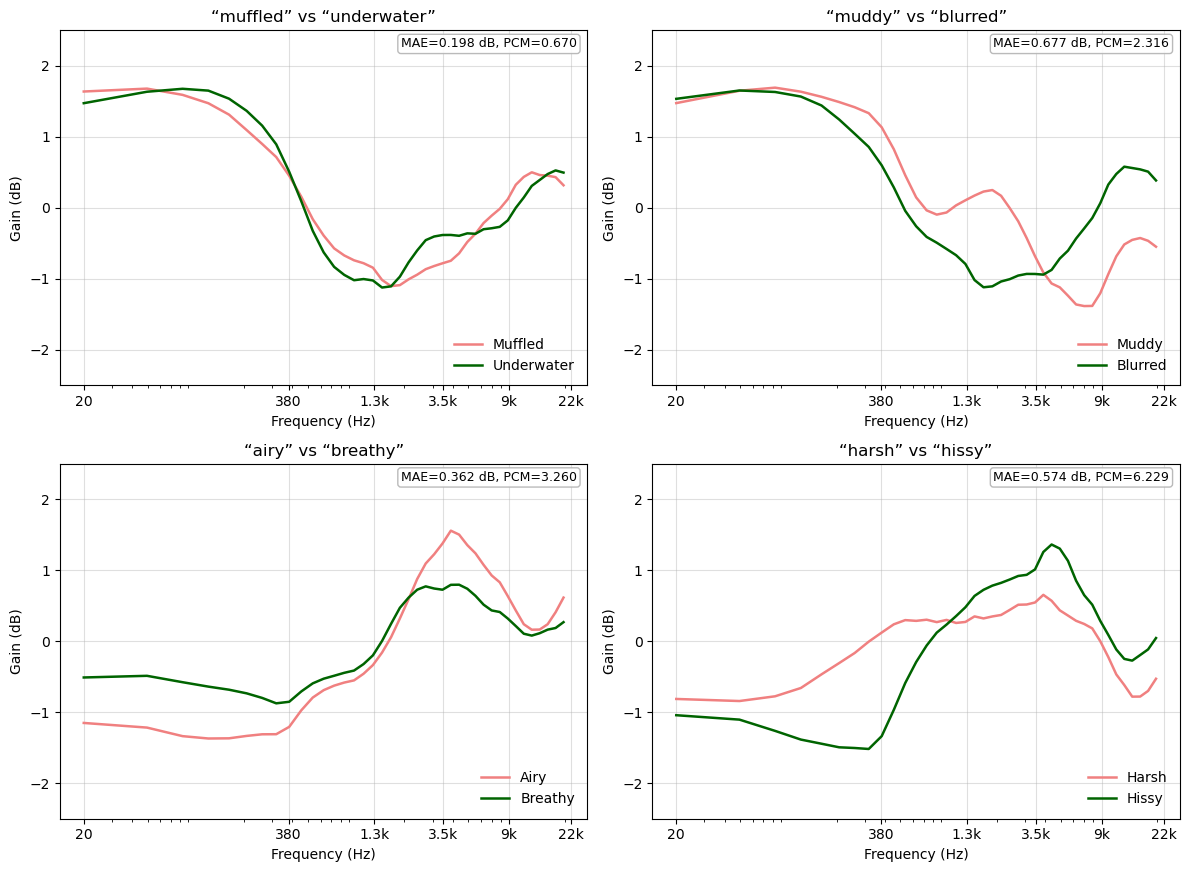

Saved metrics: ./semantic_pairs_metrics.csv


In [24]:

# 四对：图内右下角小框标注（不显眼），同时导出CSV
df, fig_path, csv_path = plot_four_pairs_fold4([
    ("muffled", "underwater"),
    ("muddy", "blurred"),
    ("airy", "breathy"),
    ("harsh", "hissy"),
], annotate="text")